# Preprocess Galaxy Zoo Dataset

This notebook turns the extracted raw Galaxy Zoo training images into a fixed-size processed dataset that later notebooks can use for degradation, reconstruction, and model training.

It uses the reusable preprocessing code in `src/galaxy_zoo_project/preprocessing.py` so the notebook and command-line workflow stay consistent.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from galaxy_zoo_project.preprocessing import PreprocessConfig, build_processed_dataset

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_IMAGE_DIR = PROJECT_ROOT / "data" / "raw" / "images_training_rev1"
RAW_LABELS_PATH = PROJECT_ROOT / "data" / "raw" / "training_solutions_rev1.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "galaxy_zoo_128"

PROJECT_ROOT, RAW_IMAGE_DIR, RAW_LABELS_PATH, PROCESSED_DIR


/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/images_training_rev1'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/training_solutions_rev1.csv'),
 PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128'))

## Configure the Preprocessing Run

Start with a small `PROCESS_LIMIT` while iterating. Set it to `None` when you want to process the full extracted training set.


In [2]:
PROCESS_LIMIT = 1000  # Set to None for the full dataset.
OUTPUT_SIZE = 128
CROP_SIZE = 256
OVERWRITE = False
SEED = 42

config = PreprocessConfig(
    project_root=PROJECT_ROOT,
    raw_image_dir=RAW_IMAGE_DIR,
    raw_labels_path=RAW_LABELS_PATH,
    output_dir=PROCESSED_DIR,
    output_size=OUTPUT_SIZE,
    crop_size=CROP_SIZE,
    limit=PROCESS_LIMIT,
    seed=SEED,
    overwrite=OVERWRITE,
)

config


PreprocessConfig(project_root=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project'), raw_image_dir=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/images_training_rev1'), raw_labels_path=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/training_solutions_rev1.csv'), output_dir=PosixPath('/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128'), output_size=128, crop_size=256, image_format='jpg', limit=1000, seed=42, val_fraction=0.1, test_fraction=0.1, overwrite=False)

## Build the Processed Dataset

This creates `data/processed/galaxy_zoo_128/images/`, `manifest.csv`, and `summary.json`. Existing images are skipped unless `OVERWRITE = True`.


In [3]:
manifest = build_processed_dataset(config)

print(f"Processed manifest rows: {len(manifest):,}")
print(f"Manifest: {(PROCESSED_DIR / 'manifest.csv').relative_to(PROJECT_ROOT)}")
print(f"Images: {(PROCESSED_DIR / 'images').relative_to(PROJECT_ROOT)}")


Preprocessing images:   0%|          | 0/1000 [00:00<?, ?image/s]

Preprocessing images:   6%|▌         | 56/1000 [00:00<00:01, 556.71image/s]

Preprocessing images:  11%|█         | 112/1000 [00:00<00:01, 492.15image/s]

Preprocessing images:  16%|█▌        | 162/1000 [00:00<00:01, 478.00image/s]

Preprocessing images:  21%|██        | 211/1000 [00:00<00:01, 467.31image/s]

...

Preprocessing images:  88%|████████▊ | 883/1000 [00:01<00:00, 471.05image/s]

Preprocessing images:  93%|█████████▎| 931/1000 [00:01<00:00, 473.24image/s]

Preprocessing images:  98%|█████████▊| 979/1000 [00:02<00:00, 474.86image/s]

Preprocessing images: 100%|██████████| 1000/1000 [00:02<00:00, 472.28image/s]

Processed manifest rows: 1,000
Manifest: data/processed/galaxy_zoo_128/manifest.csv
Images: data/processed/galaxy_zoo_128/images


## Inspect the Manifest

The manifest links every processed image back to the raw file, includes a train/validation/test split, and keeps the original Galaxy Zoo vote-probability labels.


In [4]:
manifest_path = PROCESSED_DIR / "manifest.csv"
manifest = pd.read_csv(manifest_path)

print(manifest.shape)
display(manifest.head())
display(manifest["split"].value_counts().rename_axis("split").reset_index(name="count"))


(1000, 41)


,GalaxyID,raw_path,processed_path,split,Class1.1,Class1.2,Class1.3,Class2.1,Class2.2,Class3.1,...,Class9.3,Class10.1,Class10.2,Class10.3,Class11.1,Class11.2,Class11.3,Class11.4,Class11.5,Class11.6
0,100008,data/raw/images_training_rev1/100008.jpg,data/processed/galaxy_zoo_128/images/100008.jpg,train,0.383147,0.616853,0.000000,0.000000,0.616853,0.038452,...,0.000000,0.279952,0.138445,0.000000,0.000000,0.092886,0.0,0.0,0.0,0.325512
1,100023,data/raw/images_training_rev1/100023.jpg,data/processed/galaxy_zoo_128/images/100023.jpg,train,0.327001,0.663777,0.009222,0.031178,0.632599,0.467370,...,0.018764,0.000000,0.131378,0.459950,0.000000,0.591328,0.0,0.0,0.0,0.000000
2,100053,data/raw/images_training_rev1/100053.jpg,data/processed/galaxy_zoo_128/images/100053.jpg,train,0.765717,0.177352,0.056931,0.000000,0.177352,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000
3,100078,data/raw/images_training_rev1/100078.jpg,data/processed/galaxy_zoo_128/images/100078.jpg,train,0.693377,0.238564,0.068059,0.000000,0.238564,0.109493,...,0.000000,0.094549,0.000000,0.094549,0.189098,0.000000,0.0,0.0,0.0,0.000000
4,100090,data/raw/images_training_rev1/100090.jpg,data/processed/galaxy_zoo_128/images/100090.jpg,train,0.933839,0.000000,0.066161,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000


,split,count
0,train,800
1,val,100
2,test,100


## Check Processed Image Sizes

Every processed image should have the same dimensions, which makes later degradation and reconstruction code simpler.


In [5]:
size_records = []
for processed_path in manifest["processed_path"].head(200):
    with Image.open(PROJECT_ROOT / processed_path) as image:
        size_records.append({"path": processed_path, "width": image.width, "height": image.height, "mode": image.mode})

sizes = pd.DataFrame(size_records)
display(sizes.head())
display(sizes[["width", "height", "mode"]].value_counts().reset_index(name="count"))


,path,width,height,mode
0,data/processed/galaxy_zoo_128/images/100008.jpg,128,128,RGB
1,data/processed/galaxy_zoo_128/images/100023.jpg,128,128,RGB
2,data/processed/galaxy_zoo_128/images/100053.jpg,128,128,RGB
3,data/processed/galaxy_zoo_128/images/100078.jpg,128,128,RGB
4,data/processed/galaxy_zoo_128/images/100090.jpg,128,128,RGB


,width,height,mode,count
0,128,128,RGB,200


## Preview Raw vs Processed Images

This confirms the center crop and resize are doing what we expect before we use these images as clean ground truth for computational imaging experiments.


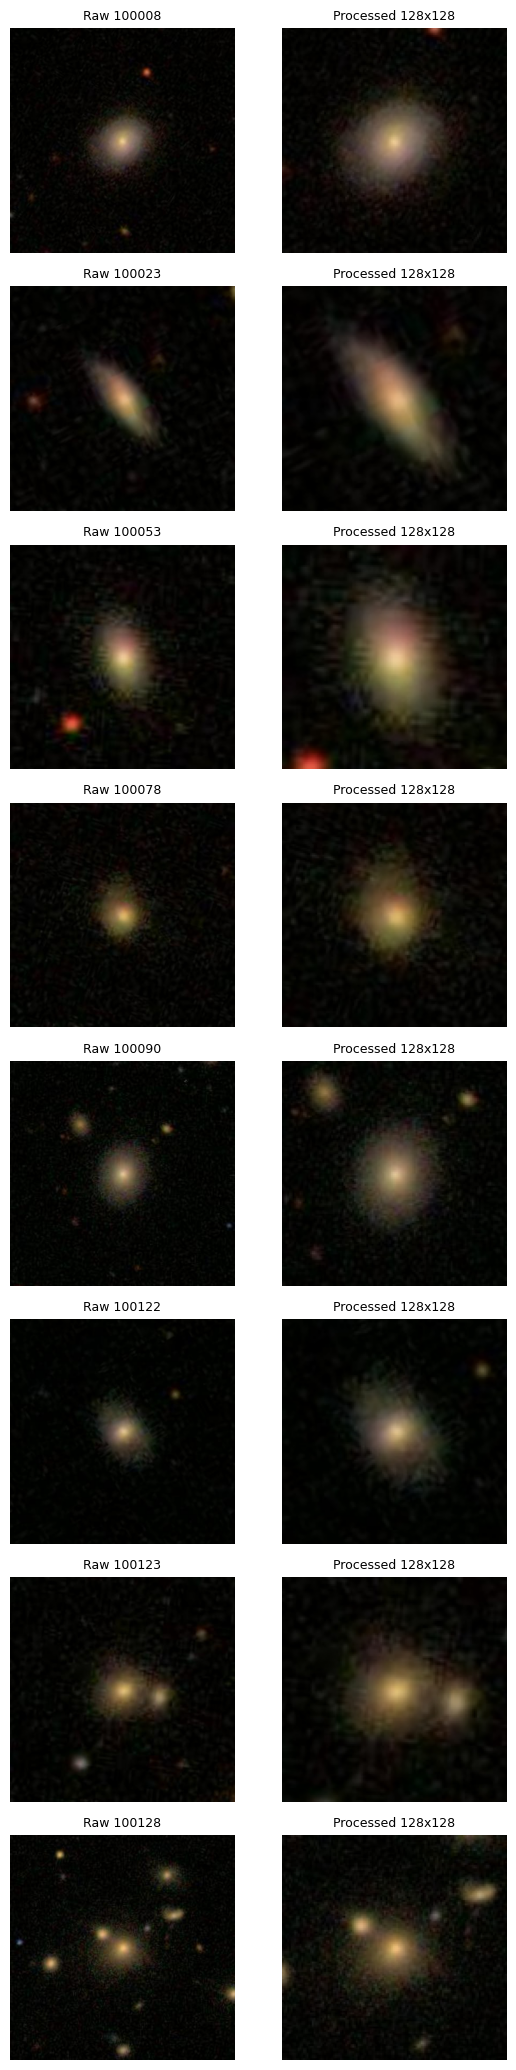

In [6]:
sample = manifest.head(8)
fig, axes = plt.subplots(len(sample), 2, figsize=(6, 2.6 * len(sample)))

for row_index, (_, row) in enumerate(sample.iterrows()):
    raw_image = Image.open(PROJECT_ROOT / row["raw_path"]).convert("RGB")
    processed_image = Image.open(PROJECT_ROOT / row["processed_path"]).convert("RGB")

    axes[row_index, 0].imshow(raw_image)
    axes[row_index, 0].set_title(f"Raw {row['GalaxyID']}", fontsize=9)
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(processed_image)
    axes[row_index, 1].set_title(f"Processed {OUTPUT_SIZE}x{OUTPUT_SIZE}", fontsize=9)
    axes[row_index, 1].axis("off")

plt.tight_layout()


## Quick Label Sanity Check

These columns are vote probabilities from Galaxy Zoo. For the next computational-imaging step, they can help us ask whether reconstruction preserves morphology-relevant structure.


In [7]:
label_columns = [column for column in manifest.columns if column.startswith("Class")]

print(f"Label columns: {len(label_columns)}")
display(manifest[label_columns].describe().T.head(20))


Label columns: 37


,count,mean,std,min,25%,50%,75%,max
Class1.1,1000.0,0.429526,0.284131,0.000000,0.173318,0.416722,0.684550,1.000000
Class1.2,1000.0,0.544846,0.297215,0.000000,0.260821,0.561083,0.812968,1.000000
Class1.3,1000.0,0.025627,0.036120,0.000000,0.000000,0.014847,0.034332,0.376913
Class2.1,1000.0,0.107591,0.219110,0.000000,0.000000,0.000000,0.082992,0.984543
Class2.2,1000.0,0.437256,0.302169,0.000000,0.171954,0.404600,0.691129,1.000000
Class3.1,1000.0,0.097581,0.163665,0.000000,0.000000,0.000000,0.142007,0.919865
Class3.2,1000.0,0.339675,0.245215,0.000000,0.129508,0.299668,0.528656,0.948253
Class4.1,1000.0,0.226866,0.292952,0.000000,0.000000,0.108540,0.347115,1.000000
Class4.2,1000.0,0.210390,0.175222,0.000000,0.065307,0.176135,0.319570,0.790494
Class5.1,1000.0,0.043110,0.092676,0.000000,0.000000,0.000000,0.044762,0.707180


## Output Summary

Use this processed dataset as the clean image set for the next notebook, where we can simulate an imaging forward model such as blur, downsampling, and sensor noise.


In [8]:
summary_path = PROCESSED_DIR / "summary.json"
print(summary_path.read_text())


{
  "config": {
    "project_root": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project",
    "raw_image_dir": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/images_training_rev1",
    "raw_labels_path": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/raw/training_solutions_rev1.csv",
    "output_dir": "/home/vm/dev/Project (Computational Imaging + Physics Applications of AI)/galaxy-zoo-project/data/processed/galaxy_zoo_128",
    "output_size": 128,
    "crop_size": 256,
    "image_format": "jpg",
    "limit": 1000,
    "seed": 42,
    "val_fraction": 0.1,
    "test_fraction": 0.1,
    "overwrite": false
  },
  "num_raw_images": 1000,
  "num_processed_images": 1000,
  "num_missing_labels": 0,
  "splits": {
    "test": 100,
    "train": 800,
    "val": 100
  },
  "manifest_path": "data/processed/galaxy_zoo_128/manifest.csv"
}

